# <span style="color:black; font-weight:bold;">Cross-omics alignment Cerebellum Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-omics Cerebellum data used in the tutorial are available at [ST.h5ad](https://drive.google.com/file/d/1yV125W2cFyVWMeAczT6LlsXdzdVQTJO3/view?usp=sharing) , [SM.h5ad](https://drive.google.com/file/d/1cKX6GXy5acFQraMrtblaF6bVvQv_zxqS/view?usp=sharing). The raw data is from [PLATO](https://doi.org/10.1016/j.cell.2024.12.023) Published in Cell.
In this tutorial we apply MAPS to align MAGIC-seq to MALDI-MS Cerebellum dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">MAGIC-seq(ST)</span>: 1677 spots and 16,116 genes   
+ <span style="color:black; font-weight:bold;">MALDI-MS(SM)</span>: 3908 spots and 491 mz  

In [1]:
from MAPS.align import Rigid_alignment
from MAPS.utils import set_seed,rotate_and_translate_spatial,create_new_color_dict,plot_2d_alignment_to_3d_flow
from MAPS.Evaluation import evaluation
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading Cross-omics Cerebellum data</span>
#### To ensure the accuracy of the scaling factor, we recommend using the slice with a larger initial coordinate range as the target_adata for learning the scaling factor.

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/Cerebellum/ST.h5ad')
source_adata.obs['batch']='ST'

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/Cerebellum/SM.h5ad')
target_adata.obs['batch']='SM'

### Rotate and translate the  MAGIC-seq(ST) Cerebellum

In [5]:
rotate_and_translate_spatial(source_adata,angle_deg=90,dx=1200,dy=800)

## <span style="color:black; font-weight:bold;">Spatial mapping of the Cerebellum before alignment</span>

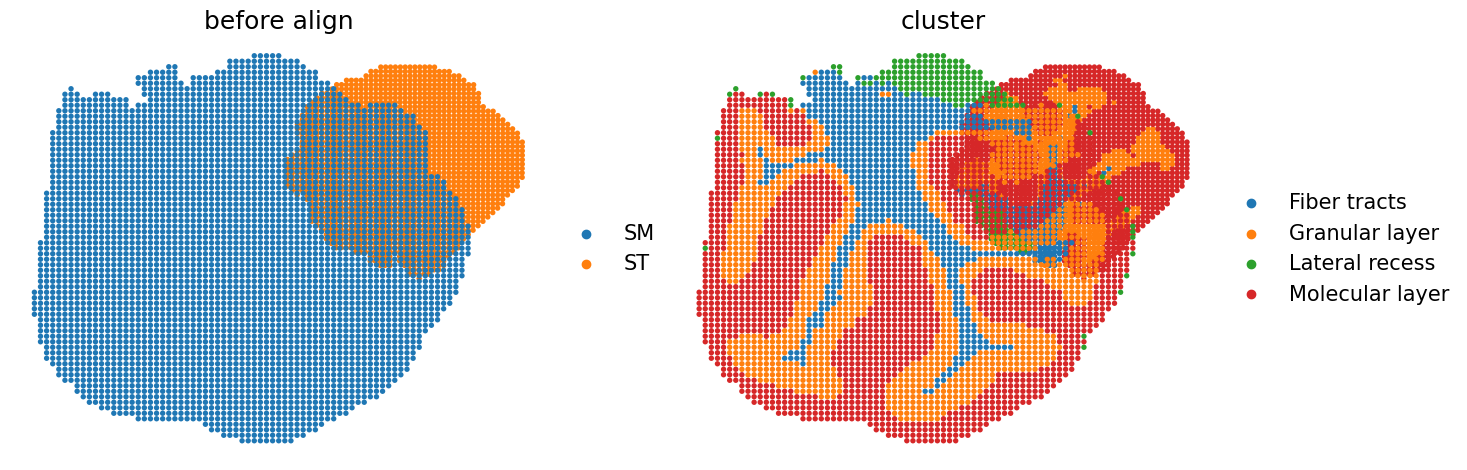

In [6]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (7,5.5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cluster'],title='before align',size=60,frameon=False)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
epochs: Training ephchs  
device: Training device  
sample_size: The number of samples used for alignment  
enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
aligned_spatial: The coordinates of the source slices after alignment  
theta_deg: Angle of rotation  
translation: Translation matrix  
scale: Scaling factor

In [7]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=1000, sample_size=20000,enable_scale=True,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████| 1000/1000 [00:02<00:00, 393.03it/s, Loss=20.80, Scale=1.889, Rot=-143.87°, Trans=(-1436.5, -836.0)]


Peak GPU memory usage: 0.143 GB
Scale factor: 1.889, Rotation angle: -143.87°, Translation (x, y): (-1436.50, -836.34)
CPU times: user 3.16 s, sys: 727 ms, total: 3.88 s
Wall time: 4.27 s


## <span style="color:black; font-weight:bold;">Spatial mapping of the Cerebellum after alignment</span>

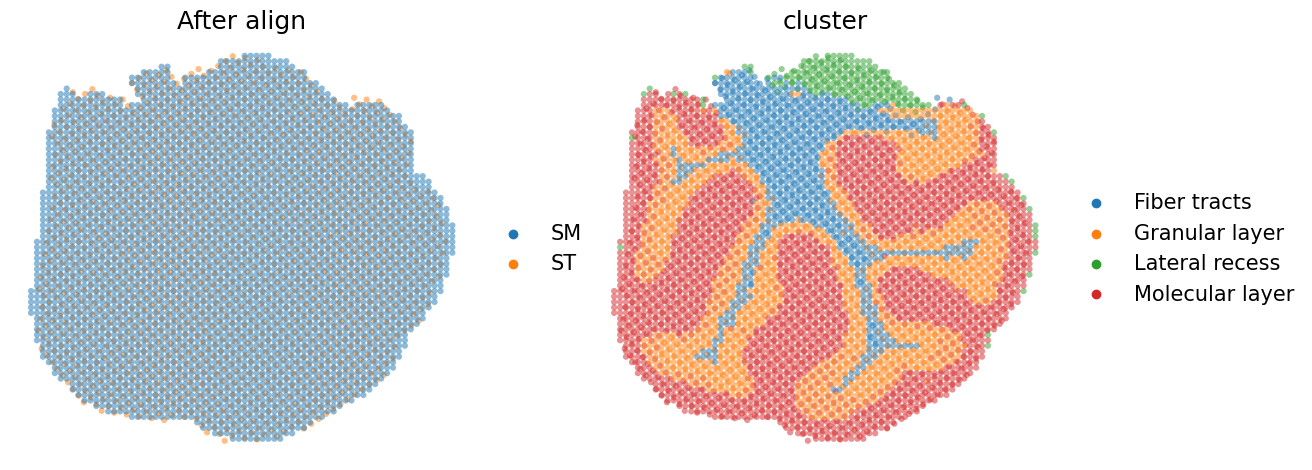

In [8]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5.5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','cluster'],title='After align',alpha=0.5,size=80,frameon=False)

## <span style="color:black; font-weight:bold;">Cell type matching index(CI)</span>

In [9]:
CI=evaluation(target_adata.obsm['spatial'],source_adata.obsm['spatial'],target_adata.obs['cluster'],source_adata.obs['cluster'])
CI

0.7865235539654144

## <span style="color:black; font-weight:bold;">Visualization of the 3D alignment flow</span>

Connected sampling (total 200):
   - Correct pairing (Black): 158
   - Incorrect pairing (red): 42


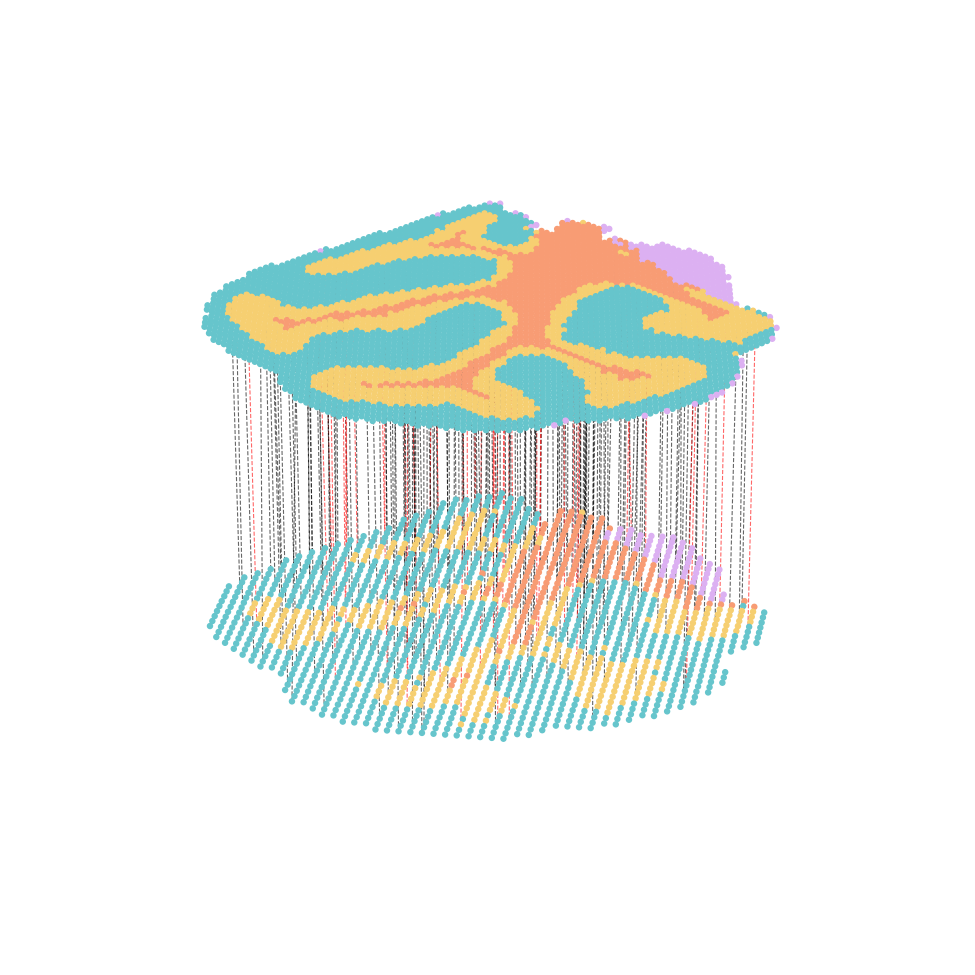

In [11]:
color_dict=create_new_color_dict(adata,cat_key='cluster')
plot_2d_alignment_to_3d_flow(
    source_adata=source_adata,
    target_adata=target_adata,
    label_key='cluster',        
    palette=color_dict,        
    n_lines=200,               
    height_scale=0.5,
    alpha_points=1,
    size=13,                  
    #save_path='/home/dbj/LPcross/Data/result/cele2/alignment_flow_3d.png'
)

## <span style="color:black; font-weight:bold;">The correct alignment ratios for different regions</span>

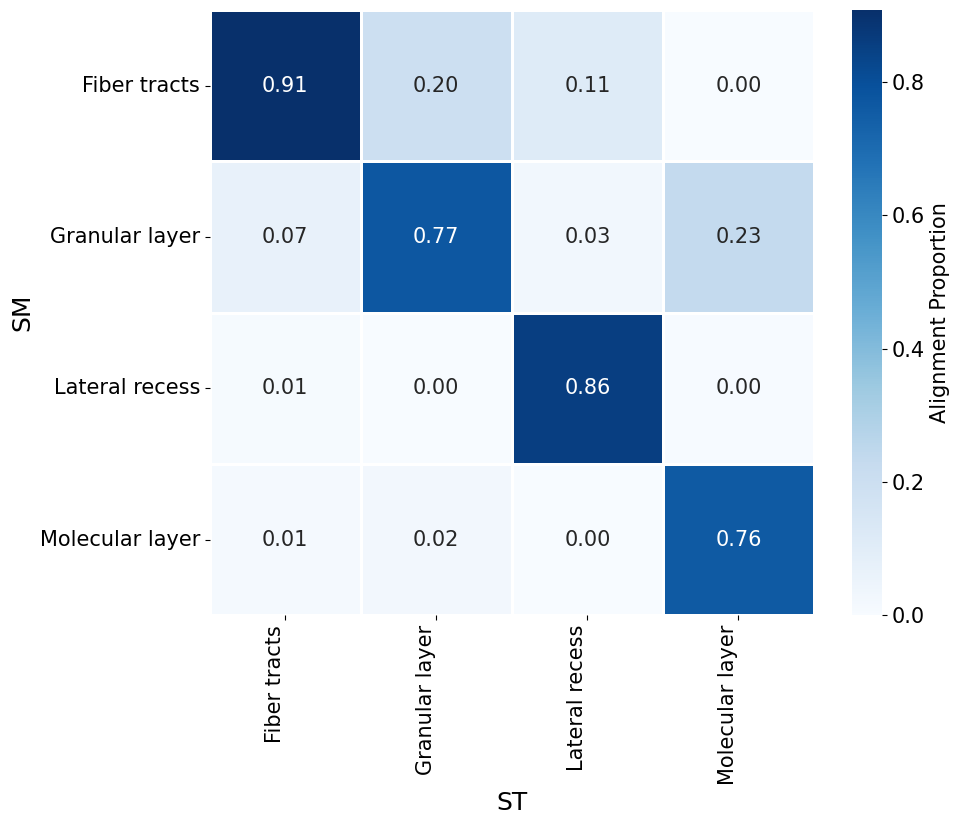

In [12]:
from scipy.spatial import cKDTree
import seaborn as sns
source_label_key = 'cluster' 
target_label_key = 'cluster'
source_coords = source_adata.obsm['spatial']  
target_coords = target_adata.obsm['spatial']

tree = cKDTree(target_coords)
distances, indices = tree.query(source_coords, k=1)

source_labels = source_adata.obs[source_label_key].values
matched_target_labels = target_adata.obs[target_label_key].iloc[indices.flatten()].values

df_crosstab = pd.crosstab(
    index=pd.Series(matched_target_labels, name='Target Labels (Y)'),
    columns=pd.Series(source_labels, name='Source Labels (X)'),
    normalize='columns' 
)

plt.figure(figsize=(10, 8.5))
sns.heatmap(df_crosstab, annot=True,cmap='Blues',fmt='.2f',linewidths=1, cbar_kws={'label': 'Alignment Proportion'})
plt.grid(False) 
plt.title('', fontsize=14, pad=15)
plt.xlabel('ST', fontsize=18)
plt.ylabel('SM', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()